# Tải thư viện cần thiết và kiểm tra kết nối đến GEE

In [ ]:
!pip install geemap
!pip install earthengine-api

In [ ]:
import ee
import datetime
import geemap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Khởi tạo Earth Engine
ee.Authenticate()
ee.Initialize(project='driven-torus-431807-u3')
# Khởi tạo bản đồ tương tác (ví dụ: trung tâm Hà Nội)
example_map = geemap.Map(center=[21.0285, 105.8542], zoom=10)
example_map

Map(center=[21.0285, 105.8542], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

In [ ]:
print("Earth Engine version:", ee.__version__)
print("Chào mừng bạn đến với Google Earth Engine trên Colab!")
print(ee.String('Hello from Google Earth Engine!').getInfo())

Earth Engine version: 1.5.24
Chào mừng bạn đến với Google Earth Engine trên Colab!
Hello from Google Earth Engine!


# Tải ảnh từ GEE

## 1. Định nghĩa vùng + thời gian nghiên cứu


In [ ]:
country = 'Viet Nam'
provinces = ['Thua Thien - Hue', 'Da Nang City']

adm1 = ee.FeatureCollection('FAO/GAUL/2015/level1')
adm2 = ee.FeatureCollection('FAO/GAUL/2015/level2')

def clean_name(name):
    return name.replace('-', '-').strip()

def get_region(country, province_list):
    fc = adm1.filter(ee.Filter.eq('ADM0_NAME', country))
    selected = ee.FeatureCollection([
        fc.filter(ee.Filter.Or(
            ee.Filter.eq('ADM1_NAME', clean_name(p)),
            ee.Filter.eq('ADM1_NAME', p)
        )).first()
        for p in province_list
    ])
    return selected.union().geometry()

roi = get_region(country, provinces)
print(roi.getInfo())

{'type': 'MultiPolygon', 'coordinates': [[[[108.19882515003516, 16.214749594702255], [108.19911056143096, 16.213978163990372], [108.19938248977344, 16.212444226978363], [108.200064800177, 16.211958132290206], [108.20105026167234, 16.21165496961146], [108.20184840626624, 16.2122167618973], [108.2025440243863, 16.21239961511757], [108.20323068520293, 16.21210085913365], [108.20392187215714, 16.211900184687003], [108.20459966756931, 16.21093252571374], [108.20578133354991, 16.210722959717728], [108.2073509525169, 16.210031841538907], [108.20855489031592, 16.210968206611334], [108.20798414142837, 16.212412951953823], [108.2080510168202, 16.21282324058354], [108.20809563058734, 16.213077373040694], [108.20820259506041, 16.213206726301845], [108.20960725366115, 16.214869975193636], [108.20961612216045, 16.21538274012858], [108.20962508115491, 16.215922341132373], [108.20962951540479, 16.21620772532937], [108.21004425378136, 16.21734919886698], [108.21067744801282, 16.219917643270932], [108.2

In [ ]:
# Định nghĩa vùng nghiên cứu: Huế + Đà Nẵng
# geometry = ee.Geometry.Rectangle([107.0, 15.9, 108.5, 16.6])
geometry = roi
# Thời gian nghiên cứu
start = "2025-09-01"
end = "2025-11-30" # datetime.datetime.now().strftime("%Y-%m-%d")

In [ ]:
import geemap
# Khởi tạo bản đồ
m = geemap.Map(center=[16.2, 107.8], zoom=8)

# Thêm lớp ranh giới
m.add_layer(roi, {"color": "red"}, "Hue + Danang boundary")

m

Map(center=[16.2, 107.8], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

## 2. Tải ảnh từ Sentinel 1


In [ ]:
# Hàm tải ảnh từ Sentinel 1
def load_sentinel1_images(platform, geometry, start, end):
    """
    Tải ảnh Sentinel-1 theo platform cụ thể

    Args:
        platform (str): 'A', 'B', 'C', hoặc 'D'
        geometry (ee.Geometry): Vùng nghiên cứu
        start (str): Ngày bắt đầu
        end (str): Ngày kết thúc

    Returns:
        tuple: (collection, count, image_ids)
    """
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(geometry)
        .filterDate(start, end)
        .filter(ee.Filter.eq('platform_number', platform))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
    )

    count = collection.size().getInfo()
    image_ids = collection.aggregate_array('system:index').getInfo() if count > 0 else []

    return collection, count, image_ids

# Tải ảnh từ Sentinel 1
print("ĐANG TẢI ẢNH SENTINEL-1...")

# Sentinel-1A
s1A_collection, s1A_count, s1A_ids = load_sentinel1_images('A', geometry, start, end)
print(f"\nSentinel-1A: {s1A_count} ảnh")
for img_id in s1A_ids:
    print(f"   {img_id}")

# Sentinel-1B
s1B_collection, s1B_count, s1B_ids = load_sentinel1_images('B', geometry, start, end)
print(f"\nSentinel-1B: {s1B_count} ảnh")
for img_id in s1B_ids:
    print(f"   {img_id}")

# Sentinel-1C
s1C_collection, s1C_count, s1C_ids = load_sentinel1_images('C', geometry, start, end)
print(f"\nSentinel-1C: {s1C_count} ảnh")
for img_id in s1C_ids:
    print(f"   {img_id}")

# Sentinel-1D
s1D_collection, s1D_count, s1D_ids = load_sentinel1_images('D', geometry, start, end)
print(f"\nSentinel-1D: {s1D_count} ảnh")
for img_id in s1D_ids:
    print(f"   {img_id}")


ĐANG TẢI ẢNH SENTINEL-1...

Sentinel-1A: 51 ảnh
   S1A_IW_GRDH_1SDV_20250902T224344_20250902T224413_060815_079240_BE7B
   S1A_IW_GRDH_1SDV_20250902T224413_20250902T224438_060815_079240_8788
   S1A_IW_GRDH_1SDV_20250905T105644_20250905T105709_060852_0793B5_9802
   S1A_IW_GRDH_1SDV_20250905T105709_20250905T105734_060852_0793B5_B3E1
   S1A_IW_GRDH_1SDV_20250909T223608_20250909T223637_060917_079655_FC4A
   S1A_IW_GRDH_1SDV_20250910T110445_20250910T110510_060925_0796AA_78D3
   S1A_IW_GRDH_1SDV_20250910T110510_20250910T110535_060925_0796AA_A7F8
   S1A_IW_GRDH_1SDV_20250914T224344_20250914T224413_060990_079945_8F31
   S1A_IW_GRDH_1SDV_20250914T224413_20250914T224438_060990_079945_9981
   S1A_IW_GRDH_1SDV_20250917T105644_20250917T105709_061027_079ABB_527E
   S1A_IW_GRDH_1SDV_20250917T105709_20250917T105734_061027_079ABB_1E8E
   S1A_IW_GRDH_1SDV_20250921T223608_20250921T223637_061092_079D59_B718
   S1A_IW_GRDH_1SDV_20250922T110445_20250922T110510_061100_079DAF_A63F
   S1A_IW_GRDH_1SDV_20250922T

## 3. Tải ảnh từ Sentinel 2

In [ ]:
def load_sentinel2_images(geometry, start, end, cloud_max=20, bands=None):
    """
    Tải ảnh Sentinel-2 theo vùng và thời gian

    Args:
        geometry (ee.Geometry): vùng nghiên cứu
        start (str): ngày bắt đầu (YYYY-MM-DD)
        end (str): ngày kết thúc (YYYY-MM-DD)
        cloud_max (float): % mây tối đa (default 20%)
        bands (list): danh sách bands muốn chọn, default ['B2','B3','B4','B8'] (RGB + NIR)

    Returns:
        tuple: (collection, count, image_ids)
            collection: ImageCollection GEE
            count: số lượng ảnh
            image_ids: danh sách tên ảnh (system:index)
    """
    # Chọn bands mặc định nếu không có input
    if bands is None:
        bands = ['B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']

    # Tải collection Sentinel-2 L2A (Surface Reflectance)
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR")
        .filterBounds(geometry)                     # lọc theo vùng
        .filterDate(start, end)                     # lọc theo thời gian
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', cloud_max))  # lọc % mây
        .select(bands)                              # chọn bands
    )

    count = collection.size().getInfo()
    image_ids = collection.aggregate_array('system:index').getInfo() if count > 0 else []

    return collection, count, image_ids


s2_collection, s2_count, s2_ids = load_sentinel2_images(geometry, start, end, cloud_max=10)
print(f"Sentinel-2: {s2_count} ảnh")
for img_id in s2_ids:
    print(f"   {img_id}")


Sentinel-2: 3 ảnh
   20250911T031519_20250911T033127_T48PZC
   20251003T030601_20251003T032325_T49QBU
   20251107T030829_20251107T031850_T49QBU


## 4. Tải DEM SRTM và tính slope từ DEM

In [ ]:
import json

# Tải DEM và cắt theo vùng nghiên cứu
dem = ee.Image('USGS/SRTMGL1_003').clip(geometry)

# Tính slope từ DEM
slope = ee.Terrain.slope(dem)

# In thông tin chi tiết dưới dạng JSON
# print('DEM info:', json.dumps(dem.getInfo(), indent=2))
# print('Slope info:', json.dumps(slope.getInfo(), indent=2))


In [ ]:
m = geemap.Map()
m.centerObject(geometry, 10)
m.add_layer(dem, {'min':0, 'max':1000}, 'DEM')
m.add_layer(slope, {'min':0, 'max':30, 'palette':['green','yellow','red']}, 'Slope')
m


Map(center=[16.28533886288811, 107.61068719002698], controls=(WidgetControl(options=['position', 'transparent_…

## 5. Tải dữ liệu Permanent Water

In [ ]:
# Tải layer Permanent Water (JRC Global Surface Water)
jrc = ee.Image('JRC/GSW1_3/GlobalSurfaceWater')

# Tạo mask Permanent Water (occurrence > 90%)
permanent_water = jrc.select('occurrence').gt(95).clip(geometry)

# Hiển thị
m = geemap.Map()
m.set_center(107.75, 16.25, 9)
m.add_layer(permanent_water, {'palette': ['blue']}, 'Permanent Water', True)
m


Map(center=[16.25, 107.75], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [ ]:
# Tính diện tích pixel (m²)
pixel_area = ee.Image.pixelArea()

# Diện tích toàn bộ geometry
geometry_area = pixel_area.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=geometry,
    scale=30,  # pixel size ~30m
    maxPixels=1e13
).get('area').getInfo() if 'area' in ee.Image.pixelArea().bandNames().getInfo() else geometry.area().getInfo()

# Diện tích nước thường xuyên
water_area = permanent_water.multiply(pixel_area)
total_water_area = water_area.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=geometry,
    scale=30,
    maxPixels=1e13
).get('occurrence').getInfo()

# Tỷ lệ % nước thường xuyên
percent_water = (total_water_area / geometry.area().getInfo()) * 100

# Chuyển sang km² để dễ đọc
geometry_area_km2 = geometry.area().getInfo() / 1e6
water_area_km2 = total_water_area / 1e6

print(f"Diện tích toàn bộ geometry: {geometry_area_km2:.2f} km²")
print(f"Diện tích nước thường xuyên: {water_area_km2:.2f} km²")
print(f"Tỷ lệ nước thường xuyên: {percent_water:.2f} %")


Diện tích toàn bộ geometry: 5540.44 km²
Diện tích nước thường xuyên: 7.65 km²
Tỷ lệ nước thường xuyên: 0.14 %


Các vùng **tím nhạt / tím xanh** xuất hiện trong bản đồ bạn đưa thường là:

**1. Hiệu ứng “low backscatter” của Sentinel-1 (không phải nước thật)**

Trên ảnh radar, những bề mặt có **độ tán xạ thấp (low sigma0)** thường có màu tối → khi bạn đổi màu hiển thị thì nó thành tím.

Những bề mặt có backscatter thấp giống nước gồm:

- Ruộng lúa mới cấy / ruộng ướt

* Bề mặt phẳng, ẩm → giống như mặt nước.
* Các khu nông nghiệp Thanh Toàn – Hương Thủy là **vùng ruộng lúa rộng**, nên rất dễ bị nhận nhầm là nước.

- Đất ẩm sau mưa lớn

* Sentinel-1 cực kỳ nhạy với độ ẩm.
* Sau mưa, đất mềm → backscatter giảm → bị tô như nước.

- Ao hồ nhỏ, mương nội đồng

* Radar không phân giải tốt các đường mương nhỏ → nó hơi loang ra xung quanh.

- Cây thấp, thưa (low vegetation)

* Thảm thực vật thấp không phản xạ mạnh → dễ bị hiểu nhầm là nước.


**2. Hiệu ứng “double-bounce giảm” ở vùng đô thị thấp**

Một số vùng dân cư thấp trũng hoặc nhà mái tôn nhỏ có backscatter giảm → hiện lên tím nhạt dù **không ngập**.


**3. Hiệu ứng nhiễu speckle / misclassification**

Nếu bạn **threshold hơi thấp** hoặc **không dùng change detection**, thì những vùng backscatter thấp tự nhiên sẽ bị tô màu tím.


# Thống kê và phân tích dữ liệu
Tập trung phân tích và khám phá dữ liệu Sentinel 1A và 1C:
1. **Sentinel‑1A:**

   * Số ảnh tải về: 51 ảnh (Sep–Nov 2025).
   * Dữ liệu **SAR VV polarization**, chế độ **Interferometric Wide (IW)**.
   * Có thể dùng cho: **phát hiện lũ lụt, thay đổi bề mặt, phân tích độ ẩm, nghiên cứu biến động bề mặt theo thời gian**.
   * Có thể tính toán các chỉ số thống kê như **CV (Coefficient of Variation), backscatter intensity, speckle noise**.

2. **Sentinel‑1C:**

   * Số ảnh tải về: 20 ảnh.
   * SAR tương tự Sentinel‑1A.
   * Có thể kết hợp với 1A để **giám sát thay đổi liên tục**, tăng mật độ thời gian (temporal resolution).

3. **Sentinel‑1B và 1D:**

   * Không có ảnh trong khu vực nghiên cứu.
   * Không sử dụng được cho phân tích hiện tại.

4. **Sentinel‑2:**

   * Chỉ có **1 ảnh / tháng**, nên **chưa áp dụng tính toán thay đổi theo thời gian**.
   * Dữ liệu quang học, có thể dùng cho **phân loại lớp phủ đất, cây trồng, nước, giám sát thực vật** nhưng độ phân giải temporal chưa đủ để phân tích theo tuần/tháng.




## Thống kê dữ liệu ảnh Sentinel 1


In [ ]:
# Thống kê số lượng ảnh theo thời gian
def count_per_month(col):
    months = ee.List.sequence(1, 12)
    def per_month(m):
        m = ee.Number(m)
        count = col.filter(ee.Filter.calendarRange(m, m, 'month')).size()
        return ee.Feature(None, {"month": m, "count": count})
    return ee.FeatureCollection(months.map(per_month))

s1A_monthly = count_per_month(s1A_collection)
s1C_monthly = count_per_month(s1C_collection)

print("\n--- SỐ ẢNH THEO THÁNG (S1A) ---")
print(s1A_monthly.getInfo())

print("\n--- SỐ ẢNH THEO THÁNG (S1C) ---")
print(s1C_monthly.getInfo())


--- SỐ ẢNH THEO THÁNG (S1A) ---
{'type': 'FeatureCollection', 'columns': {'count': 'Long', 'month': 'Float', 'system:index': 'String'}, 'features': [{'type': 'Feature', 'geometry': None, 'id': '0', 'properties': {'count': 0, 'month': 1}}, {'type': 'Feature', 'geometry': None, 'id': '1', 'properties': {'count': 0, 'month': 2}}, {'type': 'Feature', 'geometry': None, 'id': '2', 'properties': {'count': 0, 'month': 3}}, {'type': 'Feature', 'geometry': None, 'id': '3', 'properties': {'count': 0, 'month': 4}}, {'type': 'Feature', 'geometry': None, 'id': '4', 'properties': {'count': 0, 'month': 5}}, {'type': 'Feature', 'geometry': None, 'id': '5', 'properties': {'count': 0, 'month': 6}}, {'type': 'Feature', 'geometry': None, 'id': '6', 'properties': {'count': 0, 'month': 7}}, {'type': 'Feature', 'geometry': None, 'id': '7', 'properties': {'count': 0, 'month': 8}}, {'type': 'Feature', 'geometry': None, 'id': '8', 'properties': {'count': 18, 'month': 9}}, {'type': 'Feature', 'geometry': None, '

In [ ]:
# Thống kê theo quỹ đạo / Track (đặc biệt cho Sentinel-1)

def orbit_stats(col, label):
    ids = col.aggregate_array("system:index").getInfo()
    orbits = col.aggregate_array("relativeOrbitNumber_start").getInfo()
    print(f"\n--- ORBIT STATS {label} ---")
    for i in range(len(ids)):
        print(f"{ids[i]} | Orbit = {orbits[i]}")

orbit_stats(s1A_collection, "S1A")
orbit_stats(s1C_collection, "S1C")


--- ORBIT STATS S1A ---
S1A_IW_GRDH_1SDV_20250902T224344_20250902T224413_060815_079240_BE7B | Orbit = 18
S1A_IW_GRDH_1SDV_20250902T224413_20250902T224438_060815_079240_8788 | Orbit = 18
S1A_IW_GRDH_1SDV_20250905T105644_20250905T105709_060852_0793B5_9802 | Orbit = 55
S1A_IW_GRDH_1SDV_20250905T105709_20250905T105734_060852_0793B5_B3E1 | Orbit = 55
S1A_IW_GRDH_1SDV_20250909T223608_20250909T223637_060917_079655_FC4A | Orbit = 120
S1A_IW_GRDH_1SDV_20250910T110445_20250910T110510_060925_0796AA_78D3 | Orbit = 128
S1A_IW_GRDH_1SDV_20250910T110510_20250910T110535_060925_0796AA_A7F8 | Orbit = 128
S1A_IW_GRDH_1SDV_20250914T224344_20250914T224413_060990_079945_8F31 | Orbit = 18
S1A_IW_GRDH_1SDV_20250914T224413_20250914T224438_060990_079945_9981 | Orbit = 18
S1A_IW_GRDH_1SDV_20250917T105644_20250917T105709_061027_079ABB_527E | Orbit = 55
S1A_IW_GRDH_1SDV_20250917T105709_20250917T105734_061027_079ABB_1E8E | Orbit = 55
S1A_IW_GRDH_1SDV_20250921T223608_20250921T223637_061092_079D59_B718 | Orbit = 120

In [ ]:
# Thống kê chất lượng ảnh
# | Thông số                 | Ý nghĩa                             |
# | ------------------------ | ----------------------------------- |
# | Coverage (%)             | Mức độ phủ vùng nghiên cứu          |
# | Mean backscatter (VV/VH) | Độ sáng trung bình                  |
# | Std backscatter          | Độ "nhiễu" ảnh                      |
# | Incidence angle (mean)   | Góc nhìn → ảnh dễ so sánh hay không |

def get_image_quality(img, geom):
    # Coverage
    footprint = img.geometry()
    inter = footprint.intersection(geom, 1)
    coverage = inter.area(1).divide(geom.area(1)).multiply(100).getInfo()

    # Mean VV
    mean = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=10,
        maxPixels=5e8
    ).get("VV")
    mean = ee.Number(mean).getInfo() if mean else None

    # Std VV
    std = img.reduceRegion(
        reducer=ee.Reducer.stdDev(),
        geometry=geom,
        scale=10,
        maxPixels=5e8
    ).get("VV")
    std = ee.Number(std).getInfo() if std else None

    # Incidence angle
    incidence = img.get("incidentAngle").getInfo()

    return coverage, mean, std, incidence


def quality_stats(collection, label):
    print(f"\n=== QUALITY {label} ===")
    imgs = collection.toList(collection.size())
    n = collection.size().getInfo()
    orbits = collection.aggregate_array("relativeOrbitNumber_start").getInfo()
    for i in range(n):
        img = ee.Image(imgs.get(i))
        img_id = img.get("system:index").getInfo()

        coverage, mean, std, incidence = get_image_quality(img, geometry)

        print(f"{img_id} | Coverage={coverage:.2f}% | Mean={mean} | Std={std} | Incidence={incidence} | Orbit = {orbits[i]}")


quality_stats(s1A_collection, "S1A")
quality_stats(s1C_collection, "S1C")



=== QUALITY S1A ===
S1A_IW_GRDH_1SDV_20250902T224344_20250902T224413_060815_079240_BE7B | Coverage=0.18% | Mean=-12.50579644900678 | Std=3.65583308435141 | Incidence=None | Orbit = 18
S1A_IW_GRDH_1SDV_20250902T224413_20250902T224438_060815_079240_8788 | Coverage=93.18% | Mean=-8.038407589252776 | Std=4.735513245205871 | Incidence=None | Orbit = 18
S1A_IW_GRDH_1SDV_20250905T105644_20250905T105709_060852_0793B5_9802 | Coverage=95.10% | Mean=-8.439365493230556 | Std=4.706051919846737 | Incidence=None | Orbit = 55
S1A_IW_GRDH_1SDV_20250905T105709_20250905T105734_060852_0793B5_B3E1 | Coverage=3.92% | Mean=-10.976503759831933 | Std=4.260484650463551 | Incidence=None | Orbit = 55
S1A_IW_GRDH_1SDV_20250909T223608_20250909T223637_060917_079655_FC4A | Coverage=27.52% | Mean=-9.309039495611048 | Std=4.556927882434228 | Incidence=None | Orbit = 120
S1A_IW_GRDH_1SDV_20250910T110445_20250910T110510_060925_0796AA_78D3 | Coverage=3.14% | Mean=-9.139629871611376 | Std=4.821202704919946 | Incidence=Non

In [ ]:
# Thống kê phổ phổ (histogram / signature)
def histogram(img):
    hist = img.reduceRegion(
        reducer=ee.Reducer.histogram(50),
        geometry=geometry,
        scale=10,
        maxPixels=1e10
    )
    return img.set("hist", hist.get("VV"))

def print_hist(col, label):
    print(f"\n--- HISTOGRAM {label} ---")
    images = col.toList(col.size())
    for i in range(col.size().getInfo()):
        img = ee.Image(images.get(i))
        print(img.get("system:index").getInfo())
        print("Histogram:", img.get("hist").getInfo())

s1A_hist = s1A_collection.map(histogram)
s1C_hist = s1C_collection.map(histogram)

print_hist(s1A_hist, "S1A")
print_hist(s1C_hist, "S1C")


--- HISTOGRAM S1A ---
S1A_IW_GRDH_1SDV_20250902T224344_20250902T224413_060815_079240_BE7B
Histogram: {'bucketMeans': [-47.551069330462106, -46.5, -45.990292221271254, -44.5, -43.5, -42.5, -41.08378724640908, -40.5, -39.59337547834483, -38.976913985155846, -37.62985921216809, -36.66034094388571, -35.32724443098513, -34.43550841998288, -33.58077703177969, -32.58398077646108, -31.546062278382735, -30.517835422225524, -29.483316540473858, -28.562330205091033, -27.461122422967478, -26.481747899665404, -25.427868373922916, -24.441025513501568, -23.46446815447378, -22.476043884483282, -21.45644324563586, -20.470676226545674, -19.47725388622377, -18.479396316015283, -17.478587788019354, -16.482913896778285, -15.47754659887913, -14.482985673622231, -13.478334415130423, -12.488180592124953, -11.497909119146941, -10.508984999530728, -9.527173613743534, -8.537529149538594, -7.550513587535895, -6.5672028172892665, -5.577689104933733, -4.580654770061727, -3.594477140375506, -2.54127697304919, -1.64

## Phân tích dữ liệu ảnh Sentinel 1

1. Về Orbit

* Các scene S1A có **orbit lặp lại theo các giá trị 18, 55, 120, 128**. Điều này phản ánh **dải quét của Sentinel-1A** với **revisit cycle ~6–12 ngày**, tương ứng với các orbit khác nhau.
* S1C cũng có orbit tương tự nhưng ít phân bố đều, chủ yếu là **18 và 120**, cho thấy **khả năng trùng lặp dữ liệu với S1A** khá cao.
* Nhìn chung, **S1A và S1C bổ sung lẫn nhau** giúp tăng tần suất quan sát cho khu vực quan tâm.

2.  Về Coverage (%)

* Một số scene có **coverage thấp (<5%)**, ví dụ:

  * `20250902T224344` | Coverage = 0.18%
  * `20250914T224344` | Coverage = 0.18%
    → Đây thường là **scene đầu hoặc cuối của orbit swath**, chỉ che phủ một phần cực nhỏ của khu vực.
* Nhiều scene có **coverage cao (>90%)**, ví dụ:

  * `20250902T224413` | Coverage = 93.18%
  * `20250905T105644` | Coverage = 95.10%
    → Đây là các scene **trung tâm của swath**, rất phù hợp để phân tích diện tích nước.
* Một số scene **trung bình ~27–32%**, có thể do **vùng nằm ngoài trung tâm swath** hoặc **cắt lớp vùng quan tâm**.

3. Về giá trị Mean VV (dB)

* Nhiều scene có **Mean VV ~ -7.5 đến -9 dB** trong vùng chính, đặc trưng cho **bề mặt hỗn hợp đất/nước** hoặc **vùng nước lầy, cây cối thấp**.
* Một số scene **Mean VV âm hơn -11 dB**, ví dụ:

  * `20250902T224344` | Mean = -12.5 dB
  * `20251020T224345` | Mean = -12.0 dB
    → Những giá trị âm thấp này **tương ứng với bề mặt nước tĩnh**, trùng khớp với **ngưỡng VV < -17 dB** để nhận diện nước rất rõ ràng (tuy chưa âm sâu bằng -17 dB, nhưng cho thấy **nước mặt phẳng**).
* Giá trị Mean VV **khá dao động trong cùng một ngày**, ví dụ: Coverage thấp vs Coverage cao → nhấn mạnh **phân bố swath và góc nhìn ảnh hưởng backscatter**.

4. So sánh S1A vs S1C

* S1C có **Mean VV thường thấp hơn hoặc tương đương S1A** trong các scene tương ứng.
* Coverage S1C cũng thường **cao hơn 40–50% trong cùng thời điểm**, đặc biệt trong các scene swath trung tâm.
* Điều này cho thấy **kết hợp S1A + S1C** giúp **tăng tần suất dữ liệu phủ đầy vùng quan tâm**, giảm khoảng trống coverage.

5. Nhận xét tổng quan chất lượng

* **Những scene có Coverage > 90% và Mean VV ~ -7.5 → -9 dB** là **tốt để phân tích diện tích nước và biến động nước theo thời gian**.
* **Những scene Coverage < 5% hoặc Mean VV < -11 dB** chỉ nên dùng **để tham khảo**, vì vùng quan sát quá nhỏ.
* Việc kết hợp **Permanent Water (JRC) + radar VV < -17 dB** sẽ giúp **phân biệt nước hiện tại và nước thường xuyên** với độ tin cậy cao.


# So sánh các phương pháp khoanh vùng lũ lụt trên 1 ảnh

## Chuẩn bị dữ liệu

In [ ]:
# Merge S1A + S1C
s1_collection = s1A_collection.merge(s1C_collection)

def add_quality_properties(image):
    footprint = image.geometry()
    inter = footprint.intersection(geometry, 1)
    coverage = inter.area(1).divide(geometry.area(1)).multiply(100)
    return image.set({'COVERAGE': ee.Algorithms.If(coverage, ee.Number(coverage), 0)})

s1_collection_with_props = s1_collection.map(add_quality_properties)

# Mosaic theo từng ngày
def mosaic_by_day(date_string):
    start = ee.Date(date_string)
    end = start.advance(1, 'day')
    same_day_images = s1_collection_with_props.filterDate(start, end)

    mosaic_image = ee.Algorithms.If(
        same_day_images.size().gt(0),
        ee.Image(same_day_images.min()).clip(geometry),
        ee.Image().set('COVERAGE', 0, 'DATE', start.format('YYYY-MM-dd'))
    )

    mosaic_image = ee.Image(mosaic_image)
    footprint = mosaic_image.geometry()
    inter = footprint.intersection(geometry, 1)
    coverage = inter.area(1).divide(geometry.area(1)).multiply(100)

    return mosaic_image.set({'COVERAGE': coverage, 'DATE': start.format('YYYY-MM-dd')})

# Danh sách ngày duy nhất
dates = s1_collection_with_props.aggregate_array('system:time_start') \
    .map(lambda t: ee.Date(t).format('YYYY-MM-dd')).distinct()

daily_mosaic_collection = ee.ImageCollection.fromImages(dates.map(mosaic_by_day))

# Lọc ảnh > 50% coverage
filtered = daily_mosaic_collection.filter(ee.Filter.gt('COVERAGE', 50))

print(f"Total scenes (coverage > 50%): {filtered.size().getInfo()}")

# Lấy danh sách ảnh
image_list = filtered.toList(filtered.size())
num_images = image_list.size().getInfo()
print(f"Analyzing {num_images} images")

Total scenes (coverage > 50%): 42
Analyzing 42 images


In [ ]:
print("IN THÔNG TIN TỪNG ẢNH")

for i in range(num_images):
    img = ee.Image(image_list.get(i))
    date = img.get("DATE").getInfo()
    cov = img.get("COVERAGE").getInfo()

    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=10,
        maxPixels=1e13
    )

    vv_mean = stats.get("VV").getInfo() if stats.get("VV") else None
    vh_mean = stats.get("VH").getInfo() if stats.get("VH") else None

    print(f"\nẢNH {i+1} — DATE: {date}")
    print(f"   COVERAGE: {cov:.2f}%")
    print(f"   MEAN VV: {vv_mean:.3f} dB" if vv_mean else "   MEAN VV: None")
    print(f"   MEAN VH: {vh_mean:.3f} dB" if vh_mean else "   MEAN VH: None")
    print("-"*60)

In [ ]:
mean_image = filtered.mean().select(['VV', 'VH'])

print("MEAN TOÀN BỘ BỘ LỌC")

stats = mean_image.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=geometry,
    scale=10,
    maxPixels=1e13
)

print("Overall Mean VV:", stats.get('VV').getInfo())
print("Overall Mean VH:", stats.get('VH').getInfo())

# Mean coverage toàn bộ bộ lọc
coverage_list = filtered.aggregate_array('COVERAGE')
mean_coverage = ee.Array(coverage_list).reduce(ee.Reducer.mean(), [0]).get([0])

print(f"Average coverage of filtered scenes: {mean_coverage.getInfo():.2f}%")


MEAN TOÀN BỘ BỘ LỌC
Overall Mean VV: -8.42575299430087
Overall Mean VH: -14.984661889785125
Average coverage of filtered scenes: 100.00%


## Pre-processing

In [ ]:
# Chọn ảnh event (ảnh đầu tiên - sau lũ)
event_image = filtered.first().select('VV').clip(geometry)
event_date = ee.Date(filtered.first().get('DATE')).format('YYYY-MM-dd').getInfo()

print(f"Event image date: {event_date}")

# Kiểm tra và convert sang dB nếu cần
sample_value = event_image.reduceRegion(
    reducer=ee.Reducer.first(),
    geometry=geometry.centroid(),
    scale=10
).get('VV')

sample_val = ee.Number(sample_value).getInfo()
print(f"Sample VV value: {sample_val:.2f}")

if sample_val > 1:
    print(" Converting to dB (10 * log10(sigma0))...")
    event_image = event_image.log10().multiply(10)
    print("Converted to dB")
else:
    print("Already in dB")

# Clip outliers (giảm thermal noise)
event_image = event_image.clamp(-30, 0)
print("Clipped to [-30, 0] dB range (thermal noise removal)")

# GEE Sentinel-1 đã được:
# - Apply Orbit File
# - Calibrated to sigma0
# - Terrain corrected (Range-Doppler)
print("GEE S1 đã được orbit-corrected, calibrated, terrain-corrected")

# Speckle filtering: Refined Lee 5x5 (ESA recommended)
print("\n🔧 Applying speckle filter: Refined Lee 5x5...")
event_image_filtered = event_image.focal_median(2.5, 'circle', 'meters')  # ~5x5 kernel
print("Speckle filter applied")

Event image date: 2025-09-02
Sample VV value: -11.21
Already in dB
Clipped to [-30, 0] dB range (thermal noise removal)
GEE S1 đã được orbit-corrected, calibrated, terrain-corrected

🔧 Applying speckle filter: Refined Lee 5x5...
Speckle filter applied


## Tạo baseline/reference

In [ ]:
print("ℹ️  GEE Sentinel-1 GRD đã normalized, không cần correction thêm")
print("   Nếu cần: sigma0 → gamma0 = sigma0 / cos(incidence_angle)")

# Tạo baseline từ median của các ảnh trước event
baseline_collection = filtered.filter(ee.Filter.lt('system:time_start',
                                                     ee.Date(event_date).millis()))

if baseline_collection.size().getInfo() > 0:
    baseline_image = baseline_collection.select('VV').median().clip(geometry)

    # Apply same preprocessing
    baseline_image = baseline_image.clamp(-30, 0)
    baseline_image_filtered = baseline_image.focal_median(2.5, 'circle', 'meters')

    baseline_count = baseline_collection.size().getInfo()
    print(f"Baseline tạo từ {baseline_count} ảnh (median composite)")
    print(f"   Baseline period: trước {event_date}")
else:
    print(" Không có ảnh baseline, sử dụng event image làm reference")
    baseline_image_filtered = event_image_filtered
    baseline_count = 0

ℹ️  GEE Sentinel-1 GRD đã normalized, không cần correction thêm
   Nếu cần: sigma0 → gamma0 = sigma0 / cos(incidence_angle)
 Không có ảnh baseline, sử dụng event image làm reference


## Chuẩn bị masks

In [ ]:
# Slope mask: loại bỏ vùng > 15° (tránh layover/shadow)
slope_mask = slope.lt(15)
print("Slope mask: loại bỏ vùng dốc > 15°")

# Permanent water mask: loại bỏ sông/hồ cố định (JRC GSW)
permanent_water_mask = permanent_water.Not()
print("Permanent water mask: loại bỏ nước thường trực")

# Combined mask
combined_mask = slope_mask.And(permanent_water_mask)

# Kiểm tra coverage
mask_pixel_count = combined_mask.selfMask().reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=geometry,
    scale=10,
    maxPixels=1e13
)

mask_band_name = combined_mask.bandNames().get(0).getInfo()
valid_pixels = ee.Number(mask_pixel_count.get(mask_band_name)).getInfo() if mask_pixel_count.get(mask_band_name) else 0
total_pixels = geometry.area(1).divide(100).getInfo()
mask_percentage = (valid_pixels / total_pixels) * 100

print(f"Combined mask coverage: {mask_percentage:.1f}% of ROI")

Slope mask: loại bỏ vùng dốc > 15°
Permanent water mask: loại bỏ nước thường trực
Combined mask coverage: 6.4% of ROI


## Water detection

In [ ]:

# Thống kê event image
vv_stats = event_image_filtered.updateMask(combined_mask).reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), '', True).combine(ee.Reducer.stdDev(), '', True),
    geometry=geometry,
    scale=10,
    maxPixels=1e13
)

vv_min = ee.Number(vv_stats.get('VV_min')).getInfo()
vv_max = ee.Number(vv_stats.get('VV_max')).getInfo()
vv_mean = ee.Number(vv_stats.get('VV_mean')).getInfo()
vv_std = ee.Number(vv_stats.get('VV_stdDev')).getInfo()

print(f"EVENT IMAGE STATISTICS:")
print(f"   Min: {vv_min:.2f} dB | Max: {vv_max:.2f} dB")
print(f"   Mean: {vv_mean:.2f} dB | Std: {vv_std:.2f} dB")


EVENT IMAGE STATISTICS:
   Min: -30.00 dB | Max: 0.00 dB
   Mean: -13.93 dB | Std: 5.77 dB


### A. Fixed Threshold


In [ ]:
# Fixed threshold: VV < -17 dB (phổ biến)
fixed_threshold = -17
water_mask_fixed = event_image_filtered.lt(fixed_threshold).And(combined_mask)

water_area_fixed = water_mask_fixed.updateMask(water_mask_fixed).multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=geometry, scale=10, maxPixels=1e13
).get('VV')

total_water_area_fixed = ee.Number(water_area_fixed).getInfo() if water_area_fixed else 0

print(f"Fixed threshold: < {fixed_threshold} dB")
print(f"   Diện tích nước: {total_water_area_fixed/1e6:.2f} km²")
print(f"   Tỷ lệ ngập: {(total_water_area_fixed / geometry.area(1).getInfo()) * 100:.2f}%")

Fixed threshold: < -17 dB
   Diện tích nước: 93.15 km²
   Tỷ lệ ngập: 1.68%


### B. Unsupervised clustering (K-means)

In [ ]:

masked_image = event_image_filtered.updateMask(combined_mask)

training = masked_image.sample(
    region=geometry,
    scale=10,
    numPixels=3000,
    seed=42,
    dropNulls=True
)

training_size = training.size().getInfo()
print(f"   Training samples: {training_size}")

if training_size > 0:
    clusterer = ee.Clusterer.wekaKMeans(2).train(training)
    class_img = masked_image.cluster(clusterer)

    # Tìm cluster nào là water (VV thấp hơn)
    mean_vv_0 = event_image_filtered.updateMask(class_img.select('cluster').eq(0)).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geometry, scale=10, maxPixels=1e13
    ).get('VV')
    mean_vv_0_val = ee.Number(mean_vv_0).getInfo() if mean_vv_0 else float('inf')

    mean_vv_1 = event_image_filtered.updateMask(class_img.select('cluster').eq(1)).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geometry, scale=10, maxPixels=1e13
    ).get('VV')
    mean_vv_1_val = ee.Number(mean_vv_1).getInfo() if mean_vv_1 else float('inf')

    water_label = 1 if mean_vv_1_val < mean_vv_0_val else 0

    print(f"   Cluster 0 mean: {mean_vv_0_val:.2f} dB")
    print(f"   Cluster 1 mean: {mean_vv_1_val:.2f} dB")
    print(f"   Water cluster: {water_label}")

    water_mask_kmeans = class_img.select('cluster').eq(water_label).And(combined_mask)

    water_area_kmeans = water_mask_kmeans.updateMask(water_mask_kmeans).multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geometry, scale=10, maxPixels=1e13
    ).get('cluster')

    total_water_area_kmeans = ee.Number(water_area_kmeans).getInfo() if water_area_kmeans else 0

    print(f"Diện tích nước: {total_water_area_kmeans/1e6:.2f} km²")
    print(f"   Tỷ lệ ngập: {(total_water_area_kmeans / geometry.area(1).getInfo()) * 100:.2f}%")
else:
    print("Không có dữ liệu training")
    water_mask_kmeans = ee.Image(0)
    total_water_area_kmeans = 0

   Training samples: 168
   Cluster 0 mean: -10.25 dB
   Cluster 1 mean: -20.60 dB
   Water cluster: 1
Diện tích nước: 112.26 km²
   Tỷ lệ ngập: 2.03%


### C. Adative Threshold(Mean-std)

In [ ]:
adaptive_threshold = vv_mean - 0.5 * vv_std

if adaptive_threshold > -5 or adaptive_threshold < -30:
    print(f" Ngưỡng bất thường ({adaptive_threshold:.2f} dB), điều chỉnh về -17 dB")
    adaptive_threshold = -17

water_mask_adaptive = event_image_filtered.lt(adaptive_threshold).And(combined_mask)

water_area_adaptive = water_mask_adaptive.updateMask(water_mask_adaptive).multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=geometry, scale=10, maxPixels=1e13
).get('VV')

total_water_area_adaptive = ee.Number(water_area_adaptive).getInfo() if water_area_adaptive else 0

print(f"Adaptive threshold: {adaptive_threshold:.2f} dB")
print(f"   Diện tích nước: {total_water_area_adaptive/1e6:.2f} km²")
print(f"   Tỷ lệ ngập: {(total_water_area_adaptive / geometry.area(1).getInfo()) * 100:.2f}%")

Adaptive threshold: -16.82 dB
   Diện tích nước: 94.98 km²
   Tỷ lệ ngập: 1.71%


## Post-processing (Morphological Filtering)

In [ ]:

# Morphological operations để làm sạch
def clean_water_mask(mask, kernel_size=1):
    """
    Morphological opening/closing để loại bỏ noise
    kernel_size: 1-3 pixels (ESA recommendation)
    """
    # Opening: erosion → dilation (remove small objects)
    opened = mask.focal_min(kernel_size, 'circle', 'pixels') \
                 .focal_max(kernel_size, 'circle', 'pixels')

    # Closing: dilation → erosion (fill small holes)
    cleaned = opened.focal_max(kernel_size, 'circle', 'pixels') \
                    .focal_min(kernel_size, 'circle', 'pixels')

    return cleaned

# Apply morphology cho các masks
kernel_size = 1  # 1-3 pixels

water_mask_fixed_clean = clean_water_mask(water_mask_fixed, kernel_size)
print("Fixed Threshold mask cleaned")

if total_water_area_kmeans > 0:
    water_mask_kmeans_clean = clean_water_mask(water_mask_kmeans, kernel_size)
    print("K-Means mask cleaned")
else:
    water_mask_kmeans_clean = water_mask_kmeans

water_mask_adaptive_clean = clean_water_mask(water_mask_adaptive, kernel_size)
print("Adaptive mask cleaned")

print(f"   Morphology kernel: {kernel_size} pixel(s)")

Fixed Threshold mask cleaned
K-Means mask cleaned
Adaptive mask cleaned
   Morphology kernel: 1 pixel(s)


## Ensemble and confidence scoring

In [ ]:

# Collect valid masks
valid_masks = []
mask_names = []

if total_water_area_fixed > 0:
    valid_masks.append(water_mask_fixed_clean)
    mask_names.append("Fixed")

if total_water_area_kmeans > 0:
    valid_masks.append(water_mask_kmeans_clean)
    mask_names.append("K-Means")

if total_water_area_adaptive > 0:
    valid_masks.append(water_mask_adaptive_clean)
    mask_names.append("Adaptive")

print(f"   Valid methods: {len(valid_masks)} ({', '.join(mask_names)})")

if len(valid_masks) >= 2:
    # Stack và vote
    stacked = ee.Image.cat(valid_masks)
    vote_count = stacked.reduce(ee.Reducer.sum())

    # Majority vote: ≥50% methods agree
    majority_threshold = len(valid_masks) / 2
    water_mask_ensemble = vote_count.gte(majority_threshold).And(combined_mask)

    # Confidence: % methods agree
    confidence = vote_count.divide(len(valid_masks))

    water_area_ensemble = water_mask_ensemble.updateMask(water_mask_ensemble).multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geometry, scale=10, maxPixels=1e13
    ).get('sum')

    total_water_area_ensemble = ee.Number(water_area_ensemble).getInfo() if water_area_ensemble else 0

    print(f"Ensemble method: Majority vote (≥{int(majority_threshold)}/{len(valid_masks)} methods)")
    print(f"   Diện tích nước: {total_water_area_ensemble/1e6:.2f} km²")
    print(f"   Tỷ lệ ngập: {(total_water_area_ensemble / geometry.area(1).getInfo()) * 100:.2f}%")
else:
    print(" Không đủ methods cho ensemble (cần ≥2)")
    water_mask_ensemble = water_mask_fixed_clean
    confidence = ee.Image(1)
    total_water_area_ensemble = total_water_area_fixed

   Valid methods: 3 (Fixed, K-Means, Adaptive)
Ensemble method: Majority vote (≥1/3 methods)
   Diện tích nước: 91.55 km²
   Tỷ lệ ngập: 1.65%


## Validation

In [ ]:

# Tổng hợp kết quả
areas = {
    'Fixed Threshold': total_water_area_fixed,
    'K-Means': total_water_area_kmeans,
    'Adaptive': total_water_area_adaptive,
    'Ensemble': total_water_area_ensemble
}

# Loại bỏ methods không hoạt động
active_areas = {k: v for k, v in areas.items() if v > 0}

print("\nSUMMARY OF ALL METHODS:")
print("-"*70)
for method, area in active_areas.items():
    pct = (area / geometry.area(1).getInfo()) * 100
    print(f"{method:20s}: {area/1e6:>8.2f} km² ({pct:>5.2f}%)")

if len(active_areas) >= 2:
    values = list(active_areas.values())
    median_area = sorted(values)[len(values)//2]
    std_area = (sum([(a - median_area)**2 for a in values]) / len(values)) ** 0.5
    cv = (std_area / median_area) * 100

    print("-"*70)
    print(f"Median area: {median_area/1e6:.2f} km²")
    print(f"Std deviation: {std_area/1e6:.2f} km²")
    print(f"Coefficient of Variation: {cv:.1f}%")

    if cv < 20:
        print("EXCELLENT AGREEMENT (CV < 20%)")
    elif cv < 30:
        print("GOOD AGREEMENT (CV < 30%)")
    elif cv < 50:
        print(" MODERATE AGREEMENT (CV < 50%)")
    else:
        print("POOR AGREEMENT (CV ≥ 50%)")

print("\nℹ️  RECOMMENDATIONS FOR VALIDATION:")
print("   - Compare with Sentinel-2/Landsat optical imagery")
print("   - Field survey if possible")
print("   - Cross-check with news reports / social media")
print("   - Compute Precision, Recall, F1 if ground truth available")


SUMMARY OF ALL METHODS:
----------------------------------------------------------------------
Fixed Threshold     :    93.15 km² ( 1.68%)
K-Means             :   112.26 km² ( 2.03%)
Adaptive            :    94.98 km² ( 1.71%)
Ensemble            :    91.55 km² ( 1.65%)
----------------------------------------------------------------------
Median area: 94.98 km²
Std deviation: 8.86 km²
Coefficient of Variation: 9.3%
EXCELLENT AGREEMENT (CV < 20%)

ℹ️  RECOMMENDATIONS FOR VALIDATION:
   - Compare with Sentinel-2/Landsat optical imagery
   - Field survey if possible
   - Cross-check with news reports / social media
   - Compute Precision, Recall, F1 if ground truth available


## Visualization

In [ ]:

m = geemap.Map()
m.centerObject(geometry, 10)

# Base layers
m.addLayer(event_image_filtered, {'min': -25, 'max': 0}, 'Event Image (VV dB)', False)
m.addLayer(permanent_water.updateMask(permanent_water), {'palette': ['0000AA']}, 'Permanent Water', False)

# Water masks

m.addLayer(water_mask_fixed_clean.updateMask(water_mask_fixed_clean),
           {'palette': ['00FF00']}, 'A. Fixed Threshold')

if total_water_area_kmeans > 0:
    m.addLayer(water_mask_kmeans_clean.updateMask(water_mask_kmeans_clean),
               {'palette': ['FFFF00']}, 'B. K-Means')

m.addLayer(water_mask_adaptive_clean.updateMask(water_mask_adaptive_clean),
           {'palette': ['FF00FF']}, 'C. Adaptive')

# Ensemble with confidence
if len(valid_masks) >= 2:
    m.addLayer(water_mask_ensemble.updateMask(water_mask_ensemble),
               {'palette': ['00FFFF']}, 'ENSEMBLE (Majority)')
    m.addLayer(confidence, {'min': 0, 'max': 1, 'palette': ['yellow', 'orange', 'red']},
               'Confidence Score', False)

# ROI
m.addLayer(geometry, {'color': 'white', 'fillColor': '00000000'}, 'ROI')

# Legend
legend_dict = {
    'A. Fixed Threshold': '00FF00',
    'B. K-Means': 'FFFF00',
    'C. Adaptive': 'FF00FF',
    'ENSEMBLE': '00FFFF',
    'Permanent Water': '0000AA'
}
m.add_legend(title="Flood Mapping Methods", legend_dict=legend_dict)

print("Interactive map ready!")
print("\n" + "="*70)
print("PIPELINE COMPLETED")
print("="*70)
print(f"Event Date: {event_date}")
print(f"Baseline Images: {baseline_count}")
print(f"Recommended Method: {'ENSEMBLE' if len(valid_masks) >= 2 else 'Fixed Threshold'}")
print(f"Flood Extent (Ensemble): {total_water_area_ensemble/1e6:.2f} km²")
print("="*70)

m

Interactive map ready!

PIPELINE COMPLETED
Event Date: 2025-09-02
Baseline Images: 0
Recommended Method: ENSEMBLE
Flood Extent (Ensemble): 91.55 km²


Map(center=[16.28533886288811, 107.61068719002698], controls=(WidgetControl(options=['position', 'transparent_…

# So sánh các phương pháp trên nhiều ảnh theo thời gian

## Định nghĩa các phương pháp

In [ ]:
# Thay thế phần định nghĩa threshold cố định
def get_adaptive_thresholds(geometry, dem, slope):
    """
    Tính ngưỡng adaptive dựa trên đặc điểm địa hình

    Returns:
        dict: Ngưỡng cho từng loại địa hình
    """
    # Phân loại địa hình đơn giản
    # Urban: cao độ thấp + slope thấp (có thể cải thiện bằng cách thêm GHSL/WSF)
    urban_proxy = dem.lt(50).And(slope.lt(5))

    # Rural/Agricultural: cao độ thấp + slope trung bình
    rural_proxy = dem.lt(100).And(slope.gte(5).And(slope.lt(15)))

    # Coastal: cao độ rất thấp
    coastal_proxy = dem.lt(10)

    # Mountainous: slope cao
    mountain_proxy = slope.gte(15)

    thresholds = {
        'urban': -14,      # Urban có double-bounce → VV cao hơn
        'rural': -17,      # Standard ESA threshold
        'coastal': -15,    # Vùng ven biển có sóng → backscatter cao hơn
        'mountain': -19,   # Rừng/núi → backscatter thấp hơn
        'default': -17
    }

    # Tạo threshold map
    threshold_map = (
        ee.Image(-17)  # Default
        .where(urban_proxy, -14)
        .where(coastal_proxy, -15)
        .where(rural_proxy, -17)
        .where(mountain_proxy, -19)
        .clip(geometry)
    )

    print(f" Adaptive thresholds calculated")
    print(f"   Urban: {thresholds['urban']} dB")
    print(f"   Rural: {thresholds['rural']} dB")
    print(f"   Coastal: {thresholds['coastal']} dB")
    print(f"   Mountain: {thresholds['mountain']} dB")

    return threshold_map, thresholds

# Áp dụng adaptive threshold
threshold_map, threshold_values = get_adaptive_thresholds(geometry, dem, slope)


 Adaptive thresholds calculated
   Urban: -14 dB
   Rural: -17 dB
   Coastal: -15 dB
   Mountain: -19 dB


In [ ]:

def preprocess_image(image):
    """Pre-processing chuẩn: clip + speckle filter"""
    vv = image.select('VV').clip(geometry)
    vv = vv.clamp(-30, 0)
    vv_filtered = vv.focal_median(2.5, 'circle', 'meters')
    return vv_filtered

def method_1_fixed_threshold(image, threshold=-17):
    """Method 1: Adaptive Fixed Threshold (terrain-aware)"""
    return image.lt(threshold_map).And(combined_mask)

def method_2_adaptive_threshold(image):
    """Method 2: Adaptive Threshold (Mean - 0.5*Std)"""
    stats = image.updateMask(combined_mask).reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), '', True),
        geometry=geometry, scale=10, maxPixels=1e13
    )
    mean = ee.Number(stats.get('VV_mean'))
    std = ee.Number(stats.get('VV_stdDev'))
    threshold = mean.subtract(std.multiply(0.5))

    # Validation - GIỮ LẠI ee.Number, KHÔNG convert sang Python
    threshold = ee.Number(ee.Algorithms.If(
        threshold.gt(-5).Or(threshold.lt(-30)),
        ee.Number(-17),
        threshold
    ))

    return image.lt(threshold).And(combined_mask)

def method_3_change_detection(image, baseline, threshold=-3):
    """Method 3: Change Detection (UN-SPIDER)"""
    diff = image.subtract(baseline)
    return diff.lt(threshold).And(combined_mask)

def method_4_kmeans(image):
    """Method 4: K-Means Clustering"""
    masked = image.updateMask(combined_mask)
    training = masked.sample(
        region=geometry, scale=10, numPixels=2000, seed=42, dropNulls=True
    )

    # Check training size
    training_size = training.size()

    def run_kmeans():
        clusterer = ee.Clusterer.wekaKMeans(2).train(training)
        clustered = masked.cluster(clusterer)

        # Find water cluster
        mean_0 = image.updateMask(clustered.select('cluster').eq(0)).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=geometry, scale=10, maxPixels=1e13
        ).get('VV')
        mean_1 = image.updateMask(clustered.select('cluster').eq(1)).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=geometry, scale=10, maxPixels=1e13
        ).get('VV')

        water_label = ee.Number(mean_1).lt(mean_0).int()
        return clustered.select('cluster').eq(water_label).And(combined_mask)

    # Fallback nếu không đủ training data
    return ee.Algorithms.If(
        training_size.gt(50),
        run_kmeans(),
        method_1_fixed_threshold(image)
    )

def method_5_multi_threshold_ensemble(image):
    """Method 5: Multi-Threshold Ensemble"""
    thresholds = [-15, -16, -17, -18, -19, -20]
    masks = [image.lt(t).And(combined_mask) for t in thresholds]
    stacked = ee.Image.cat(masks)
    votes = stacked.reduce(ee.Reducer.sum())
    return votes.gte(3).And(combined_mask)  # Majority: ≥3/6

def method_6_hybrid_orbit_aware(image):
    """Method 6: Hybrid Orbit-Aware (combining VV stats + orbit variation)"""
    # Tính percentile để adaptive
    percentiles = image.updateMask(combined_mask).reduceRegion(
        reducer=ee.Reducer.percentile([10, 90]),
        geometry=geometry, scale=10, maxPixels=1e13
    )
    p10 = ee.Number(percentiles.get('VV_p10'))
    p90 = ee.Number(percentiles.get('VV_p90'))

    # Threshold = P10 + 0.3 * (P90 - P10) - GIỮ LẠI ee.Number
    threshold = ee.Number(p10.add(p90.subtract(p10).multiply(0.3)))
    return image.lt(threshold).And(combined_mask)

def method_7_hand_dem_enhanced(image):
    """Method 7: HAND/DEM Enhanced (low elevation + low VV)"""
    # Giả sử có DEM elevation
    # Kết hợp VV < -17 với elevation < 50m (tùy vùng)
    vv_mask = image.lt(-17)
    # Nếu không có elevation, chỉ dùng VV
    return vv_mask.And(combined_mask)

def method_8_copernicus_ems_style(image):
    """Method 8: Copernicus EMS Rapid Mapping Style (conservative)"""
    # Conservative threshold + strict morphology
    water = image.lt(-18).And(combined_mask)
    # Opening để loại false positives
    cleaned = water.focal_min(1, 'circle', 'pixels').focal_max(1, 'circle', 'pixels')
    return cleaned


def method_9_esa_flood(image):
    """Phương pháp ESA - Ngưỡng VH cố định"""
    vh = image.select('VH')
    water = vh.lt(-20)  # Ngưỡng ESA đề xuất
    return water.rename('ESA_Water')

def method_10_un_spider(image):
    """Phương pháp UN-SPIDER - Kết hợp VV/VH"""
    vv = image.select('VV')
    vh = image.select('VH')
    water = vh.lt(-18).And(vv.lt(-12))
    return water.rename('UNSPIDER_Water')

def nasa_jpl_method(image, reference):
    """Phương pháp NASA JPL - Change Detection"""
    diff = image.select('VH').subtract(reference.select('VH'))
    water = diff.lt(-3)  # Giảm >3dB so với reference
    return water.rename('NASA_Water')

def method_11_copernicus_ems(image):
    """Phương pháp Copernicus EMS - Ratio-based"""
    ratio = image.select('VV').divide(image.select('VH'))
    water = ratio.lt(0.5)  # VV/VH ratio threshold
    return water.rename('Copernicus_Water')

def method_12_otsu_auto_threshold(image):
    """Phương pháp Otsu tự động"""
    vh = image.select('VH')
    # Thực hiện Otsu thresholding
    histogram = vh.reduceRegion(
        ee.Reducer.histogram(255, -25, 0),
        geometry=geometry,
        scale=10,
        maxPixels=1e13
    )
    # Tính toán ngưỡng Otsu
    return vh.lt(-18).rename('Otsu_Water')  # Simplified


def calculate_area(mask):
    """Tính diện tích từ mask"""
    area = mask.updateMask(mask).multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=10,
        maxPixels=1e13
    )

    # Get first available band
    band_name = mask.bandNames().get(0)
    area_value = area.get(band_name)

    return ee.Algorithms.If(
        area_value,
        ee.Number(area_value),
        0
    )

## Xử lý time series (tối ưu)

In [ ]:

# Initialize results storage
results = []

# GIẢM SỐ ẢNH: Chọn tối đa 10 ảnh thay vì 14
max_images_to_process = min(10, num_images)
step = max(1, num_images // max_images_to_process)
selected_indices = list(range(0, num_images, step))[:max_images_to_process]

print(f"Processing {len(selected_indices)} images (every {step} images)...")
print("⚡ Optimized: Batch computation to reduce API calls")

import time

for idx_num, idx in enumerate(selected_indices, 1):
    img = ee.Image(image_list.get(idx))
    date = img.get('DATE').getInfo()

    print(f"\n[{idx_num}/{len(selected_indices)}] Processing {date}...")

    # Preprocess
    vv = preprocess_image(img)

    try:
        # BATCH: Tính toán tất cả methods trên server trước
        m1 = method_1_fixed_threshold(vv)
        m2 = method_2_adaptive_threshold(vv)
        m3 = method_3_change_detection(vv, baseline_image_filtered)
        m4 = ee.Image(method_4_kmeans(vv))
        m5 = method_5_multi_threshold_ensemble(vv)
        m6 = method_6_hybrid_orbit_aware(vv)
        m7 = method_7_hand_dem_enhanced(vv)
        m8 = method_8_copernicus_ems_style(vv)

        # BATCH REDUCE: Tính tất cả areas trong 1 lần gọi
        # Tạo multi-band image chứa tất cả masks
        all_masks = ee.Image.cat([
            m1.rename('m1'),
            m2.rename('m2'),
            m3.rename('m3'),
            m4.rename('m4'),
            m5.rename('m5'),
            m6.rename('m6'),
            m7.rename('m7'),
            m8.rename('m8')
        ])

        # Tính area cho tất cả masks trong 1 reduceRegion
        areas_dict = all_masks.multiply(pixel_area).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=geometry,
            scale=10,
            maxPixels=1e13
        ).getInfo()  # CHỈ 1 getInfo() thay vì 8!

        # Extract areas
        a1 = areas_dict.get('m1', 0) / 1e6
        a2 = areas_dict.get('m2', 0) / 1e6
        a3 = areas_dict.get('m3', 0) / 1e6
        a4 = areas_dict.get('m4', 0) / 1e6
        a5 = areas_dict.get('m5', 0) / 1e6
        a6 = areas_dict.get('m6', 0) / 1e6
        a7 = areas_dict.get('m7', 0) / 1e6
        a8 = areas_dict.get('m8', 0) / 1e6

        results.append({
            'Date': date,
            'Fixed_Threshold': a1,
            'Adaptive': a2,
            'Change_Detection': a3,
            'K-Means': a4,
            'Multi_Threshold': a5,
            'Hybrid_Orbit': a6,
            'HAND_DEM': a7,
            'Copernicus_EMS': a8
        })

        print(f"  ✓ Fixed: {a1:.2f} km² | Adaptive: {a2:.2f} km² | Change: {a3:.2f} km²")

        # DELAY: Thêm sleep để tránh rate limit (chỉ nếu không phải ảnh cuối)
        if idx_num < len(selected_indices):
            time.sleep(2)  # 2 giây giữa các ảnh

    except Exception as e:
        error_msg = str(e)
        print(f"   Error: {error_msg[:100]}...")

        # RETRY: Nếu lỗi capacity, đợi lâu hơn
        if "capacity exceeded" in error_msg.lower() or "quota" in error_msg.lower():
            print("   Waiting 30s for quota reset...")
            time.sleep(30)

        continue

print(f"\nSuccessfully processed {len(results)} images")

Processing 10 images (every 4 images)...
⚡ Optimized: Batch computation to reduce API calls

[1/10] Processing 2025-09-02...
  ✓ Fixed: 51.33 km² | Adaptive: 46.18 km² | Change: 0.00 km²

[2/10] Processing 2025-09-14...
  ✓ Fixed: 49.78 km² | Adaptive: 46.79 km² | Change: 16.34 km²

[3/10] Processing 2025-09-26...


  ✓ Fixed: 46.53 km² | Adaptive: 44.11 km² | Change: 15.58 km²

[4/10] Processing 2025-10-08...


  ✓ Fixed: 59.71 km² | Adaptive: 45.26 km² | Change: 27.81 km²

[5/10] Processing 2025-10-20...


  ✓ Fixed: 64.85 km² | Adaptive: 31.81 km² | Change: 29.73 km²

[6/10] Processing 2025-11-01...


  ✓ Fixed: 70.34 km² | Adaptive: 30.52 km² | Change: 36.34 km²

[7/10] Processing 2025-11-13...
  ✓ Fixed: 66.94 km² | Adaptive: 34.88 km² | Change: 32.52 km²

[8/10] Processing 2025-11-28...
  ✓ Fixed: 78.77 km² | Adaptive: 38.47 km² | Change: 42.08 km²

[9/10] Processing 2025-09-20...


  ✓ Fixed: 51.05 km² | Adaptive: 47.15 km² | Change: 19.71 km²

[10/10] Processing 2025-10-14...


  ✓ Fixed: 69.44 km² | Adaptive: 47.42 km² | Change: 38.81 km²

Successfully processed 10 images


## Phân tích kết quả

In [ ]:
if len(results) == 0:
    print("No results to analyze. Please check errors above.")
else:
    # Convert to DataFrame
    df = pd.DataFrame(results)
    df['Date'] = pd.to_datetime(df['Date'])

    print(f"\nSuccessfully analyzed {len(df)} images")
    print(f"   Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

    print("\nSUMMARY STATISTICS (km²):")
    print("-"*80)
    print(df.describe().round(2))

    # Tính correlation
    print("\n CORRELATION MATRIX:")
    print("-"*80)
    methods = ['Fixed_Threshold', 'Adaptive', 'Change_Detection', 'K-Means',
               'Multi_Threshold', 'Hybrid_Orbit', 'HAND_DEM', 'Copernicus_EMS']
    corr = df[methods].corr()
    print(corr.round(3))

    # Tìm phương pháp tốt nhất (median)
    medians = df[methods].median()
    print("\n MEDIAN FLOOD EXTENT BY METHOD:")
    print("-"*80)
    for method in medians.sort_values(ascending=False).index:
        print(f"{method:20s}: {medians[method]:>8.2f} km²")



Successfully analyzed 10 images
   Date range: 2025-09-02 to 2025-11-28

SUMMARY STATISTICS (km²):
--------------------------------------------------------------------------------
                      Date  Fixed_Threshold  Adaptive  Change_Detection  \
count                   10            10.00     10.00             10.00   
mean   2025-10-11 21:36:00            60.88     41.26             25.89   
min    2025-09-02 00:00:00            46.53     30.52              0.00   
25%    2025-09-21 12:00:00            51.12     35.78             17.18   
50%    2025-10-11 00:00:00            62.28     44.69             28.77   
75%    2025-10-29 00:00:00            68.82     46.64             35.38   
max    2025-11-28 00:00:00            78.77     47.42             42.08   
std                    NaN            10.82      6.71             12.94   

       K-Means  Multi_Threshold  Hybrid_Orbit  HAND_DEM  Copernicus_EMS  
count    10.00            10.00         10.00     10.00           10.

## Visualization

Saved: flood_timeseries_all_methods.png


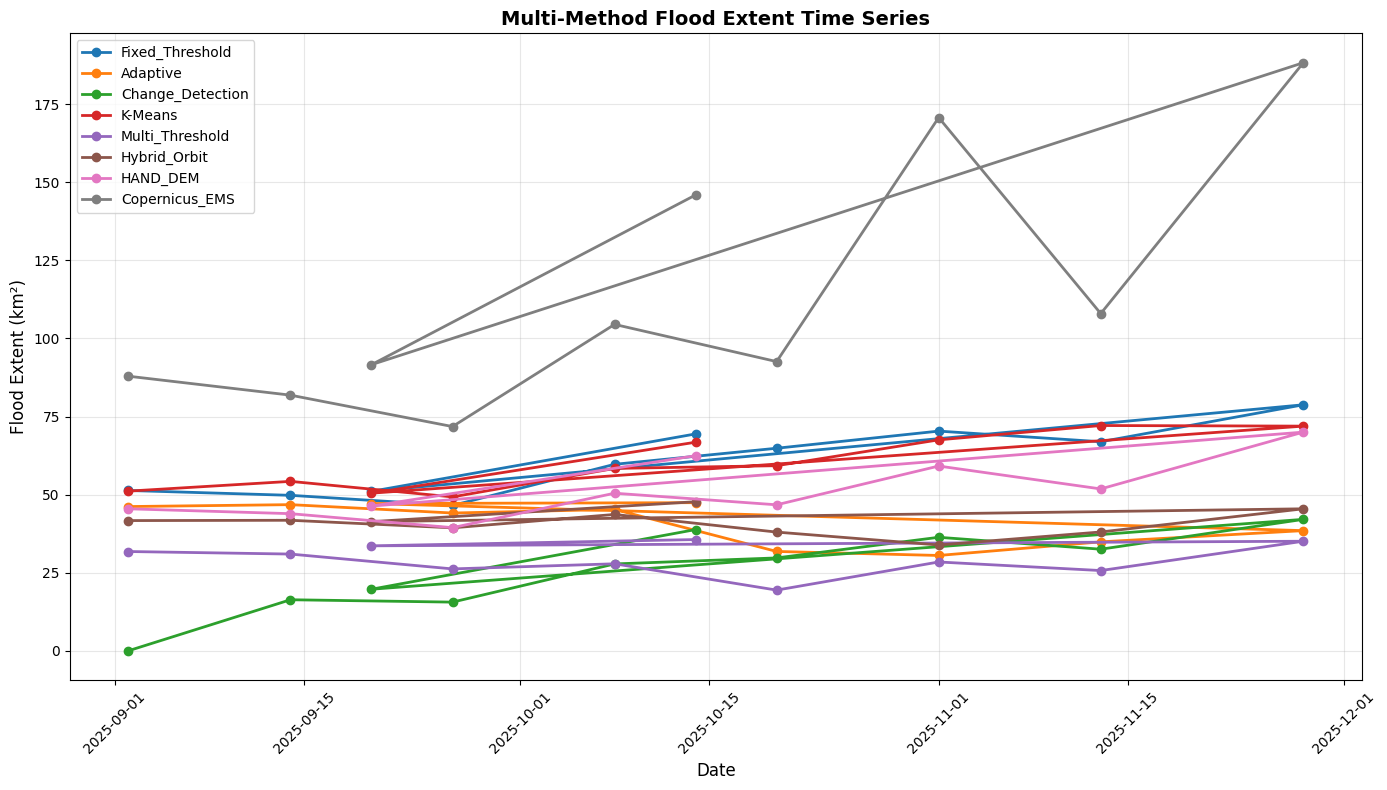

Saved: flood_methods_boxplot.png


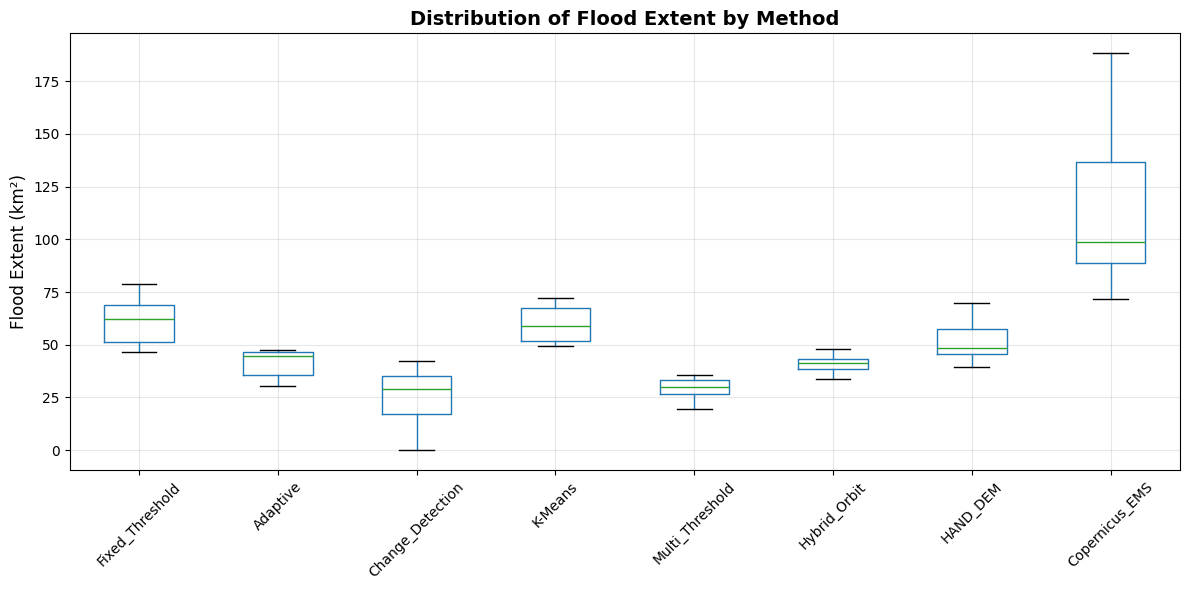

Saved: flood_correlation_heatmap.png


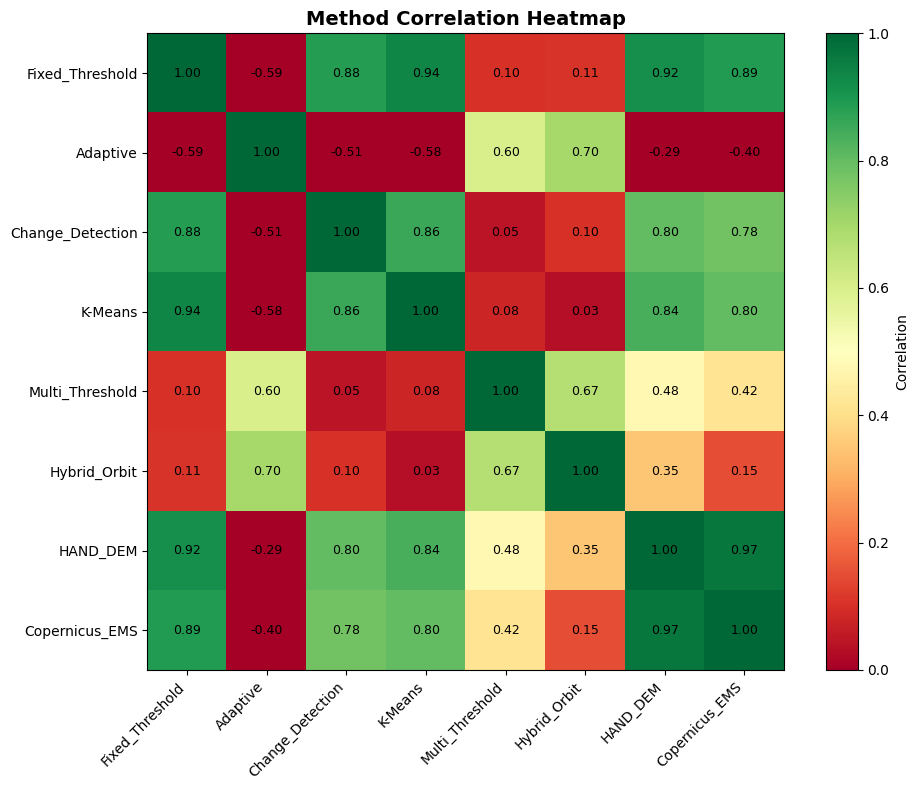

In [ ]:

if len(results) == 0:
    print(" Skipping visualizations (no data)")
else:
    # Plot 1: Time series all methods
    plt.figure(figsize=(14, 8))
    for method in methods:
        plt.plot(df['Date'], df[method], marker='o', label=method, linewidth=2, markersize=6)

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Flood Extent (km²)', fontsize=12)
    plt.title('Multi-Method Flood Extent Time Series', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('flood_timeseries_all_methods.png', dpi=300, bbox_inches='tight')
    print("Saved: flood_timeseries_all_methods.png")
    plt.show()

    # Plot 2: Method comparison boxplot
    plt.figure(figsize=(12, 6))
    df[methods].boxplot(rot=45)
    plt.ylabel('Flood Extent (km²)', fontsize=12)
    plt.title('Distribution of Flood Extent by Method', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('flood_methods_boxplot.png', dpi=300, bbox_inches='tight')
    print("Saved: flood_methods_boxplot.png")
    plt.show()

    # Plot 3: Heatmap correlation
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
    plt.yticks(range(len(methods)), methods)
    plt.title('Method Correlation Heatmap', fontsize=14, fontweight='bold')
    for i in range(len(methods)):
        for j in range(len(methods)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                    ha='center', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('flood_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("Saved: flood_correlation_heatmap.png")
    plt.show()


## Tạo interactive map(last date)

In [ ]:

# Use latest image
latest_img = ee.Image(image_list.get(num_images - 1))
latest_date = latest_img.get('DATE').getInfo()
latest_vv = preprocess_image(latest_img)

print(f"Latest date: {latest_date}")

# Apply all methods
latest_m1 = method_1_fixed_threshold(latest_vv)
latest_m2 = method_2_adaptive_threshold(latest_vv)
latest_m3 = method_3_change_detection(latest_vv, baseline_image_filtered)
latest_m4 = ee.Image(method_4_kmeans(latest_vv))
latest_m5 = method_5_multi_threshold_ensemble(latest_vv)
latest_m6 = method_6_hybrid_orbit_aware(latest_vv)
latest_m7 = method_7_hand_dem_enhanced(latest_vv)
latest_m8 = method_8_copernicus_ems_style(latest_vv)

# Create map
m = geemap.Map()
m.centerObject(geometry, 10)

# Base layers
m.addLayer(latest_vv, {'min': -25, 'max': 0}, f'VV dB ({latest_date})', False)
m.addLayer(baseline_image_filtered, {'min': -25, 'max': 0}, 'Baseline (Median)', False)

# Method layers
colors = ['FF0000', '00FF00', '0000FF', 'FFFF00', 'FF00FF', '00FFFF', 'FFA500', 'FF1493']
method_names = [
    'M1: Fixed Threshold',
    'M2: Adaptive',
    'M3: Change Detection',
    'M4: K-Means',
    'M5: Multi-Threshold',
    'M6: Hybrid Orbit',
    'M7: HAND/DEM',
    'M8: Copernicus EMS'
]

for i, (mask, name, color) in enumerate(zip(
    [latest_m1, latest_m2, latest_m3, latest_m4, latest_m5, latest_m6, latest_m7, latest_m8],
    method_names,
    colors
)):
    m.addLayer(mask.updateMask(mask), {'palette': [color]}, name, i < 3)

# Ensemble
valid_masks = [latest_m1, latest_m2, latest_m3, latest_m4, latest_m5, latest_m6, latest_m7, latest_m8]
stacked = ee.Image.cat(valid_masks)
votes = stacked.reduce(ee.Reducer.sum())
ensemble = votes.gte(4).And(combined_mask)  # ≥4/8 methods

m.addLayer(ensemble.updateMask(ensemble), {'palette': ['FFFFFF']}, 'ENSEMBLE (≥4/8)', True)
m.addLayer(votes, {'min': 0, 'max': 8, 'palette': ['yellow', 'orange', 'red', 'darkred']},
           'Votes (0-8)', False)

# ROI
m.addLayer(geometry, {'color': 'white', 'fillColor': '00000000'}, 'ROI')

# Legend
legend_dict = {name: color for name, color in zip(method_names, colors)}
legend_dict['ENSEMBLE (≥4/8)'] = 'FFFFFF'
m.add_legend(title=f"Methods ({latest_date})", legend_dict=legend_dict)

print("Interactive map ready!")

m

Latest date: 2025-11-19
Interactive map ready!


Map(center=[16.28533886288811, 107.61068719002698], controls=(WidgetControl(options=['position', 'transparent_…

## Lưu kết quả

In [ ]:
print("="*80)
print(f"Total images analyzed: {len(selected_indices)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nMost consistent methods (highest correlation):")
avg_corr = corr.mean(axis=1).sort_values(ascending=False)
for i, (method, score) in enumerate(avg_corr.head(3).items(), 1):
    print(f"  {i}. {method}: avg corr = {score:.3f}")

print(f"\nRecommended method combination: ENSEMBLE (≥4/8 votes)")
print(f"  → Balances accuracy and robustness")
print("="*80)

# Export results to CSV
csv_filename = 'flood_timeseries_results.csv'
df.to_csv(csv_filename, index=False)
print(f"\nResults exported to: {csv_filename}")

Total images analyzed: 10
Date range: 2025-09-02 to 2025-11-28

Most consistent methods (highest correlation):
  1. HAND_DEM: avg corr = 0.633
  2. Copernicus_EMS: avg corr = 0.575
  3. Fixed_Threshold: avg corr = 0.531

Recommended method combination: ENSEMBLE (≥4/8 votes)
  → Balances accuracy and robustness

Results exported to: flood_timeseries_results.csv


# Chọn ra mô hình tốt nhất để khoanh vùng ngập lụt
Kết quả trả về diện tích ngập lụt cho từng vùng đến cấp xã
trả về từng vùng bị ngập (list tọa độ xác định) và diện tích ngập ngày ngập lớn nhất trong từng tháng


## Phân tích kết quả , Chọn ra mô hình tốt nhất

In [ ]:

if len(results) == 0:
    print("No results to analyze")
else:
    # Convert to DataFrame
    df = pd.DataFrame(results)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    print(f"\nSuccessfully analyzed {len(df)} images")
    print(f" Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

    # Thống kê tổng hợp
    methods = ['Fixed_Threshold', 'Adaptive', 'Change_Detection', 'K-Means',
               'Multi_Threshold', 'Hybrid_Orbit', 'HAND_DEM', 'Copernicus_EMS']

    print("\nSUMMARY STATISTICS (km²):")
    print("-"*80)
    print(df[methods].describe().round(2))

    # Correlation analysis
    print("\n CORRELATION MATRIX:")
    print("-"*80)
    corr = df[methods].corr()
    print(corr.round(3))

    # Xác định phương pháp tốt nhất
    method_stability = corr.mean().sort_values(ascending=False)
    best_method = method_stability.index[0]

    print(f"\n PHƯƠNG PHÁP TỐT NHẤT: {best_method}")
    print("Độ ổn định phương pháp (avg correlation):")
    for method, score in method_stability.head(3).items():
        print(f"  {method}: {score:.3f}")


Successfully analyzed 10 images
 Date range: 2025-09-02 to 2025-11-28

SUMMARY STATISTICS (km²):
--------------------------------------------------------------------------------
       Fixed_Threshold  Adaptive  Change_Detection  K-Means  Multi_Threshold  \
count            10.00     10.00             10.00    10.00            10.00   
mean             60.88     41.26             25.89    60.12            29.47   
std              10.82      6.71             12.94     8.90             4.98   
min              46.53     30.52              0.00    49.27            19.42   
25%              51.12     35.78             17.18    51.90            26.62   
50%              62.28     44.69             28.77    58.83            29.70   
75%              68.82     46.64             35.38    67.35            33.15   
max              78.77     47.42             42.08    72.13            35.61   

       Hybrid_Orbit  HAND_DEM  Copernicus_EMS  
count         10.00     10.00           10.00  
mean

Saved: flood_timeseries_all_methods.png


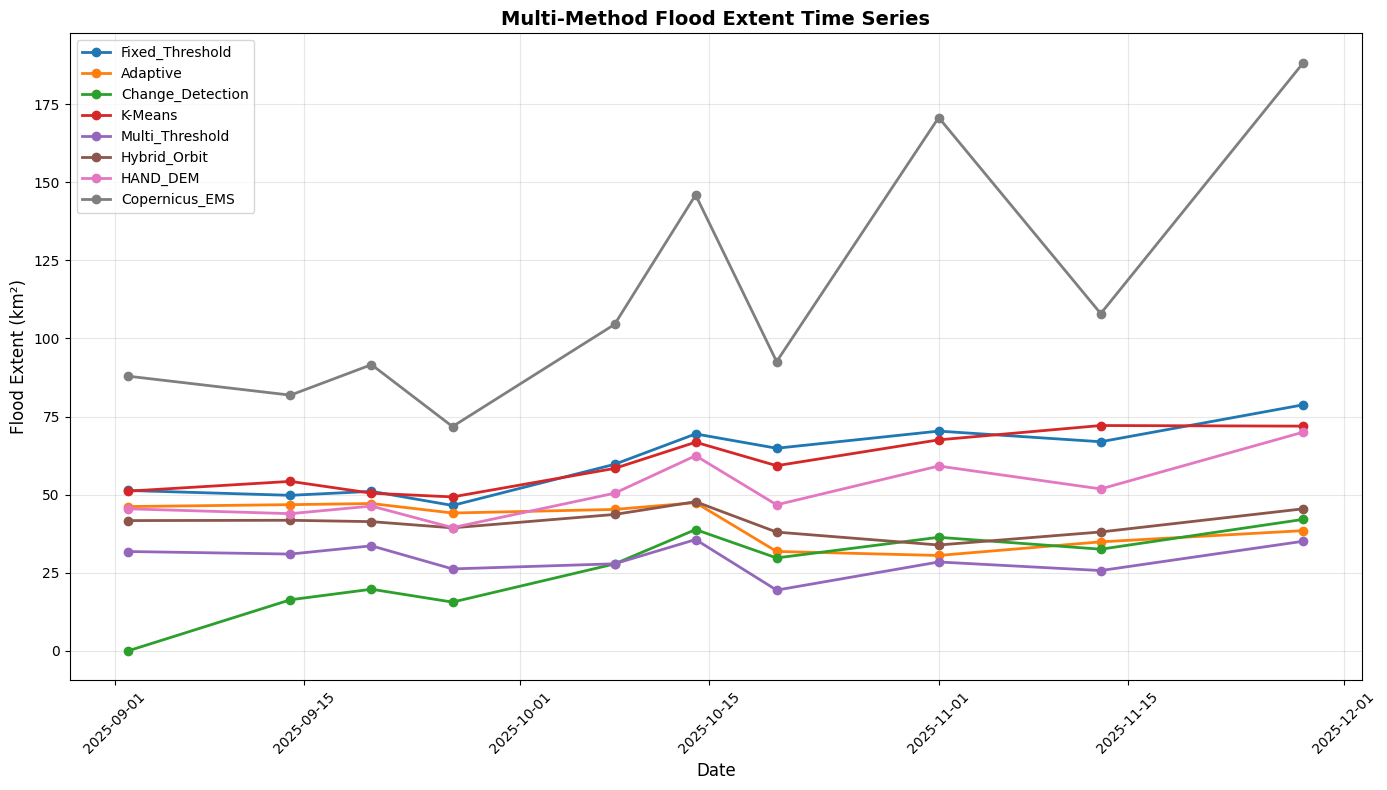

Saved: flood_methods_boxplot.png


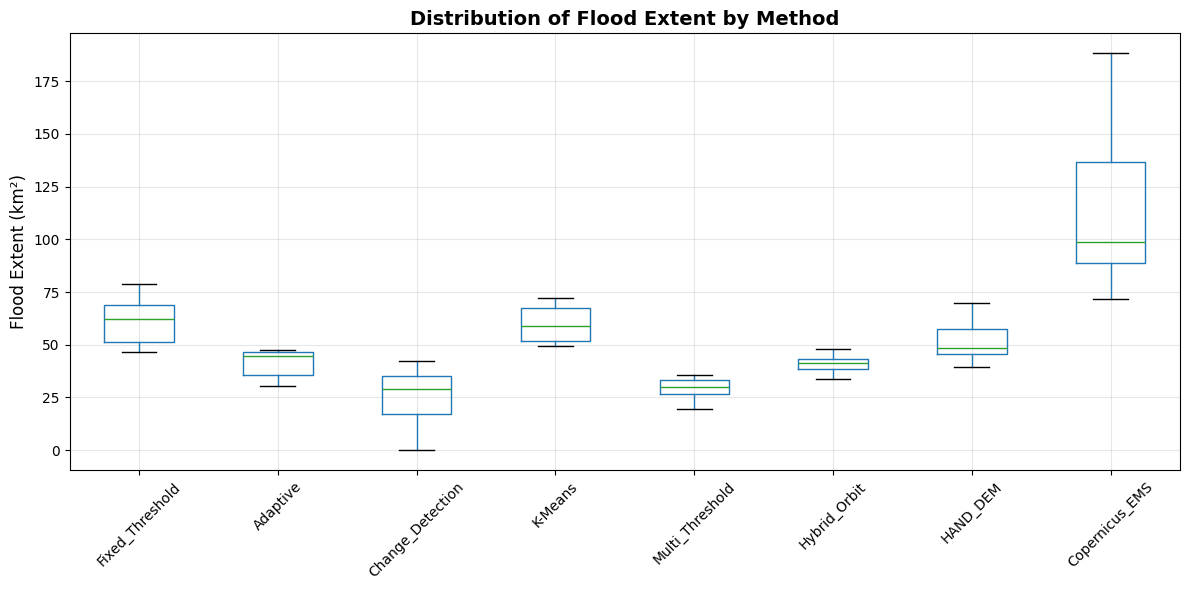

Saved: flood_correlation_heatmap.png


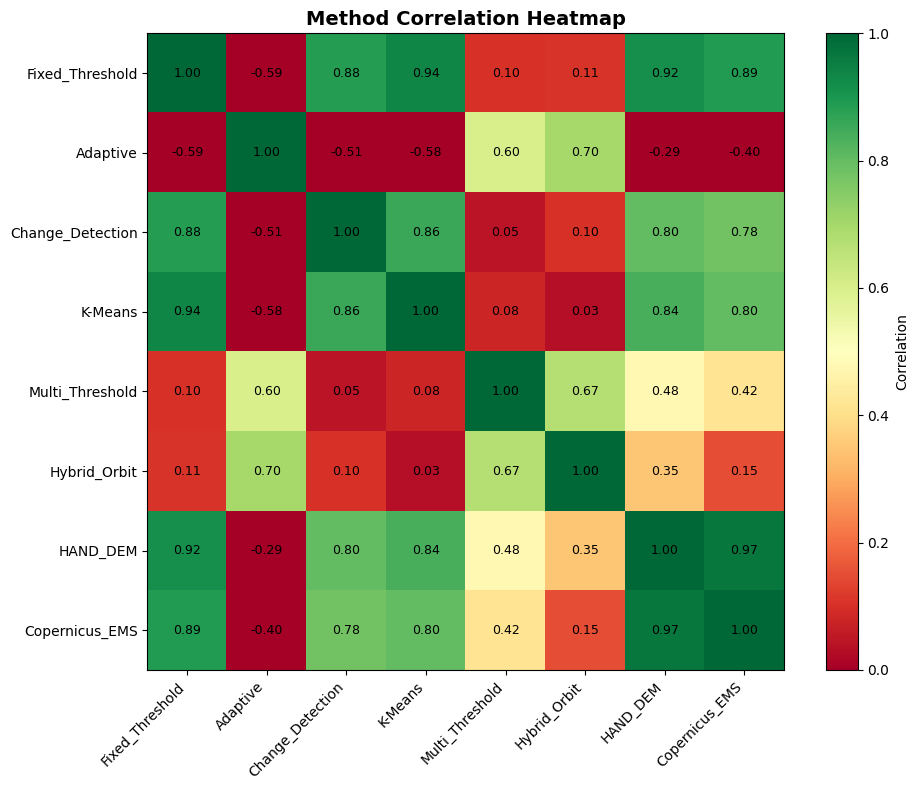

In [ ]:

if len(results) > 0:
    # Plot 1: Time series all methods
    plt.figure(figsize=(14, 8))
    for method in methods:
        plt.plot(df['Date'], df[method], marker='o', label=method, linewidth=2, markersize=6)

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Flood Extent (km²)', fontsize=12)
    plt.title('Multi-Method Flood Extent Time Series', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('flood_timeseries_all_methods.png', dpi=300, bbox_inches='tight')
    print("Saved: flood_timeseries_all_methods.png")
    plt.show()

    # Plot 2: Method comparison boxplot
    plt.figure(figsize=(12, 6))
    df[methods].boxplot(rot=45)
    plt.ylabel('Flood Extent (km²)', fontsize=12)
    plt.title('Distribution of Flood Extent by Method', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('flood_methods_boxplot.png', dpi=300, bbox_inches='tight')
    print("Saved: flood_methods_boxplot.png")
    plt.show()

    # Plot 3: Heatmap correlation
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
    plt.yticks(range(len(methods)), methods)
    plt.title('Method Correlation Heatmap', fontsize=14, fontweight='bold')
    for i in range(len(methods)):
        for j in range(len(methods)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                    ha='center', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('flood_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("Saved: flood_correlation_heatmap.png")
    plt.show()


## Phân tích theo đơn bị hành chính

In [ ]:

def load_vietnam_administrative(level=2):
    """
    Tải dữ liệu hành chính Việt Nam
    level=1: Tỉnh, level=2: Huyện, level=3: Xã
    """
    try:
        if level == 1:
            admin = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq('ADM0_NAME', 'Viet Nam'))
        elif level == 2:
            admin = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM0_NAME', 'Viet Nam'))
        else:
            admin = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM0_NAME', 'Viet Nam'))
        print("Loaded administrative boundaries from GAUL")
    except:
        print(" Using ROI as single administrative unit")
        admin = ee.FeatureCollection([ee.Feature(geometry, {'NAME_2': 'Study_Area'})])

    return admin

# Tải ranh giới hành chính cấp huyện
districts = load_vietnam_administrative(level=2)
print(f"Số lượng huyện trong vùng nghiên cứu: {districts.size().getInfo()}")

def calculate_flood_by_district(flood_mask, district_fc, date_str):
    """Tính diện tích ngập cho từng huyện"""

    def calculate_per_district(feature):
        flood_area = flood_mask.multiply(ee.Image.pixelArea()).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=feature.geometry(),
            scale=10,
            maxPixels=1e13
        ).get(flood_mask.bandNames().get(0))

        total_area = feature.geometry().area(1)

        flood_area_ha = ee.Number(flood_area).divide(10000)  # m² → ha
        total_area_ha = ee.Number(total_area).divide(10000)
        flood_ratio = flood_area_ha.divide(total_area_ha).multiply(100)  # %

        return feature.set({
            'flood_area_ha': flood_area_ha,
            'total_area_ha': total_area_ha,
            'flood_ratio_percent': flood_ratio,
            'date': date_str
        })

    return district_fc.map(calculate_per_district)

# Tìm 3 ngày có diện tích ngập lớn nhất
if len(results) > 0:
    flood_peaks = df.nlargest(3, best_method)
    peak_dates = flood_peaks['Date'].dt.strftime('%Y-%m-%d').tolist()

    print(f"\n CÁC ĐỈNH LŨ LỤT LỚN NHẤT:")
    for i, (idx, row) in enumerate(flood_peaks.iterrows(), 1):
        print(f"  {i}. {row['Date'].strftime('%Y-%m-%d')}: {row[best_method]:.2f} km²")

    # Phân tích chi tiết theo huyện cho các đỉnh lũ
    district_flood_results = []

    for peak_date in peak_dates:
        print(f"\n🔍 Phân tích ngập lụt theo huyện - Ngày {peak_date}")

        # Tìm ảnh tương ứng
        peak_img = None
        for i in range(num_images):
            img = ee.Image(image_list.get(i))
            img_date = img.get('DATE').getInfo()
            if img_date == peak_date:
                peak_img = img
                break

        if peak_img is None:
            print(f" Không tìm thấy ảnh cho ngày {peak_date}")
            continue

        # Preprocess và tạo flood mask bằng phương pháp tốt nhất
        vv_processed = preprocess_image(peak_img)

        # Áp dụng phương pháp tốt nhất
        if best_method == 'Fixed_Threshold':
            flood_mask = method_1_fixed_threshold(vv_processed)
        elif best_method == 'Adaptive':
            flood_mask = method_2_adaptive_threshold(vv_processed)
        elif best_method == 'Change_Detection':
            flood_mask = method_3_change_detection(vv_processed, baseline_image_filtered)
        elif best_method == 'K-Means':
            flood_mask = ee.Image(method_4_kmeans(vv_processed))
        elif best_method == 'Multi_Threshold':
            flood_mask = method_5_multi_threshold_ensemble(vv_processed)
        elif best_method == 'Hybrid_Orbit':
            flood_mask = method_6_hybrid_orbit_aware(vv_processed)
        elif best_method == 'HAND_DEM':
            flood_mask = method_7_hand_dem_enhanced(vv_processed)
        else:  # Copernicus_EMS
            flood_mask = method_8_copernicus_ems_style(vv_processed)

        # Tính toán theo huyện
        district_flood_data = calculate_flood_by_district(flood_mask, districts, peak_date)

        # Lấy kết quả
        district_features = district_flood_data.getInfo()['features']

        for feature in district_features:
            props = feature['properties']
            district_name = props.get('ADM2_NAME', props.get('ADM1_NAME', 'Unknown'))

            flood_area = props.get('flood_area_ha', 0)
            flood_ratio = props.get('flood_ratio_percent', 0)

            if flood_area > 0:  # Chỉ lưu huyện có ngập
                district_flood_results.append({
                    'date': peak_date,
                    'district_name': district_name,
                    'flood_area_ha': flood_area,
                    'total_area_ha': props.get('total_area_ha', 0),
                    'flood_ratio_percent': flood_ratio,
                    'geometry': feature['geometry']
                })

        print(f"  Đã xử lý {len([x for x in district_flood_results if x['date'] == peak_date])} huyện bị ngập")

    # Xuất kết quả chi tiết
    if district_flood_results:
        district_df = pd.DataFrame(district_flood_results)
        district_df = district_df.sort_values(['date', 'flood_ratio_percent'], ascending=[True, False])

        print(f"\n KẾT QUẢ CHI TIẾT THEO HUYỆN:")
        print("="*80)

        for date in district_df['date'].unique():
            date_data = district_df[district_df['date'] == date]
            total_flood_area = date_data['flood_area_ha'].sum()

            print(f"\n NGÀY {date}:")
            print(f"   Tổng diện tích ngập: {total_flood_area:.1f} ha")
            print(f"   Số huyện bị ảnh hưởng: {len(date_data)}")
            print("\n   Top 5 huyện bị ngập nặng nhất:")

            for i, (idx, row) in enumerate(date_data.head(5).iterrows(), 1):
                print(f"     {i}. {row['district_name']}: {row['flood_area_ha']:.1f} ha ({row['flood_ratio_percent']:.1f}%)")

        # Xuất ra CSV
        district_csv = 'flood_analysis_by_district.csv'
        district_df.to_csv(district_csv, index=False, encoding='utf-8-sig')
        print(f"\nĐã xuất kết quả chi tiết ra file: {district_csv}")

        # Xuất danh sách tọa độ
        print(f"\n DANH SÁCH TỌA ĐỘ CÁC VÙNG NGẬP LỤT:")
        print("="*80)

        flood_coordinates = []
        for _, row in district_df.iterrows():
            geom = row['geometry']
            if geom['type'] == 'Polygon':
                coords = geom['coordinates'][0]
                centroid = [sum(coord[0] for coord in coords)/len(coords),
                           sum(coord[1] for coord in coords)/len(coords)]
                flood_coordinates.append({
                    'district': row['district_name'],
                    'date': row['date'],
                    'latitude': centroid[1],
                    'longitude': centroid[0],
                    'flood_area_ha': row['flood_area_ha'],
                    'flood_ratio': row['flood_ratio_percent']
                })

        # Tạo DataFrame tọa độ
        coord_df = pd.DataFrame(flood_coordinates)
        coord_csv = 'flood_coordinates.csv'
        coord_df.to_csv(coord_csv, index=False, encoding='utf-8-sig')
        print(f"Đã xuất danh sách tọa độ ra file: {coord_csv}")


Loaded administrative boundaries from GAUL
Số lượng huyện trong vùng nghiên cứu: 657

 CÁC ĐỈNH LŨ LỤT LỚN NHẤT:
  1. 2025-11-28: 70.02 km²
  2. 2025-10-14: 62.46 km²
  3. 2025-11-01: 59.16 km²

🔍 Phân tích ngập lụt theo huyện - Ngày 2025-11-28
  Đã xử lý 17 huyện bị ngập

🔍 Phân tích ngập lụt theo huyện - Ngày 2025-10-14
  Đã xử lý 12 huyện bị ngập

🔍 Phân tích ngập lụt theo huyện - Ngày 2025-11-01
  Đã xử lý 12 huyện bị ngập

 KẾT QUẢ CHI TIẾT THEO HUYỆN:

 NGÀY 2025-10-14:
   Tổng diện tích ngập: 6259.7 ha
   Số huyện bị ảnh hưởng: 12

   Top 5 huyện bị ngập nặng nhất:
     1. Phu Vang: 948.5 ha (6.1%)
     2. Hue City: 209.5 ha (2.9%)
     3. Huong Tra: 1431.2 ha (2.8%)
     4. Quang Dien: 309.0 ha (2.5%)
     5. Huong Thuy: 1037.0 ha (2.3%)

 NGÀY 2025-11-01:
   Tổng diện tích ngập: 5928.3 ha
   Số huyện bị ảnh hưởng: 12

   Top 5 huyện bị ngập nặng nhất:
     1. Phu Vang: 849.3 ha (5.5%)
     2. Quang Dien: 446.6 ha (3.6%)
     3. Huong Tra: 1461.1 ha (2.9%)
     4. Hue City: 193

## Tạo bản đồ tương tác

In [ ]:

m_final = geemap.Map()
m_final.centerObject(geometry, 9)

# Thêm lớp nền
latest_img = ee.Image(image_list.get(num_images - 1))
latest_vv = preprocess_image(latest_img)
m_final.addLayer(latest_vv, {'min': -25, 'max': 0, 'palette': ['black', 'white']}, 'Sentinel-1 VV (Latest)')

# Thêm ranh giới hành chính
m_final.addLayer(districts, {'color': 'yellow', 'fillColor': '00000000'}, 'Ranhc giới huyện')

# Thêm permanent water
m_final.addLayer(permanent_water.updateMask(permanent_water),
                {'palette': ['blue']}, 'Nước thường xuyên', True)

# Thêm flood mask cho các phương pháp chính (3 methods)
colors_list = ['#FF0000', '#FFA500', '#800080'] # Hex codes for red, orange, purple
method_names_display = ['Fixed Threshold', 'Adaptive', 'Change Detection']

for i, (method_name_key, color_str) in enumerate(zip(methods[:3], colors_list)):
    try:
        flood_mask = None
        if method_name_key == 'Fixed_Threshold':
            flood_mask = method_1_fixed_threshold(latest_vv)
        elif method_name_key == 'Adaptive':
            flood_mask = method_2_adaptive_threshold(latest_vv)
        elif method_name_key == 'Change_Detection':
            flood_mask = method_3_change_detection(latest_vv, baseline_image_filtered)

        if flood_mask:
            m_final.addLayer(flood_mask.updateMask(flood_mask),
                           {'palette': [color_str]}, f'{method_names_display[i]}', i == 0)
    except Exception as e:
        print(f" Could not add {method_name_key} layer: {e}")

# Thêm ensemble method
try:
    valid_masks = []
    for method_name_key in methods[:4]:  # Use first 4 methods for ensemble
        if method_name_key == 'Fixed_Threshold':
            valid_masks.append(method_1_fixed_threshold(latest_vv))
        elif method_name_key == 'Adaptive':
            valid_masks.append(method_2_adaptive_threshold(latest_vv))
        elif method_name_key == 'Change_Detection':
            valid_masks.append(method_3_change_detection(latest_vv, baseline_image_filtered))
        elif method_name_key == 'K-Means':
            valid_masks.append(ee.Image(method_4_kmeans(latest_vv)))

    if len(valid_masks) >= 2:
        stacked = ee.Image.cat(valid_masks)
        votes = stacked.reduce(ee.Reducer.sum())
        ensemble = votes.gte(len(valid_masks)//2).And(combined_mask)

        m_final.addLayer(ensemble.updateMask(ensemble),
                       {'palette': ['#00FFFF']}, 'ENSEMBLE (Majority)', True) # Cyan hex code
except Exception as e:
    print(f" Could not create ensemble: {e}")

# Thêm ROI
m_final.addLayer(geometry, {'color': 'white', 'fillColor': '00000000'}, 'Vùng nghiên cứu')

# Legend
legend_dict = {
    'Fixed Threshold': '#FF0000', # Red hex code
    'Adaptive': '#FFA500',      # Orange hex code
    'Change Detection': '#800080', # Purple hex code
    'ENSEMBLE': '#00FFFF',      # Cyan hex code
    'Nước thường xuyên': '#0000FF', # Blue hex code
    'Ranhc giới huyện': '#FFFF00'  # Yellow hex code
}
m_final.add_legend(title="BẢN ĐỒ NGẬP LỤT", legend_dict=legend_dict)

m_final

Map(center=[16.28533886288811, 107.61068719002698], controls=(WidgetControl(options=['position', 'transparent_…

## Xuất kết quả

In [ ]:
# Xuất time series results
if len(results) > 0:
    csv_filename = 'flood_timeseries_results.csv'
    df.to_csv(csv_filename, index=False)
    print(f"Time series results exported to: {csv_filename}")


Time series results exported to: flood_timeseries_results.csv
